# Name: Momin Hosan Emon
# Email: mominhasanemon@gmail.com

In [189]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
df = pd.read_csv("titanic_data_updated.csv")
df.set_index("PassengerId", inplace =True)

# Q1

In [190]:
print(f"Shape :{df.shape}")
display(df.head(10))
print("\nSample:")
display(df.sample(5))

Shape :(891, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S



Sample:


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
487,yes,first,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,35.0,1,0,19943,90.000,C93,S
355,no,third,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.225,NaN,C
153,no,third,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.050,NaN,S
343,no,second,"Collander, Mr. Erik Gustaf",male,28.0,0,0,248740,13.000,NaN,S
489,no,third,"Somerton, Mr. Francis William",male,30.0,0,0,A.5. 18509,8.050,NaN,S


# Q2

In [191]:
print("Total missing values:")
print(df.isnull().sum(),"\n")
print("Total duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Total missing values:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64 

Total duplicate rows: 0


# Q3

In [192]:
display(df.info())
display(df.describe()) #Statistical Summary
print("Two Ovserbations: The dataset has missing values in some columns, especially Age and Cabin,\nso data cleaning or filling missing values is needed before using it for analysis or modeling.\nThe Fare column is not evenly distributed.\nA few very high values make the average much larger than the median, showing that the data is right-skewed.")

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    object 
 1   Pclass    891 non-null    object 
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 83.5+ KB


None

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


Two Ovserbations: The dataset has missing values in some columns, especially Age and Cabin,
so data cleaning or filling missing values is needed before using it for analysis or modeling.
The Fare column is not evenly distributed.
A few very high values make the average much larger than the median, showing that the data is right-skewed.


# Q4

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64
2 insights: Most of the people died. Data is imbalanced


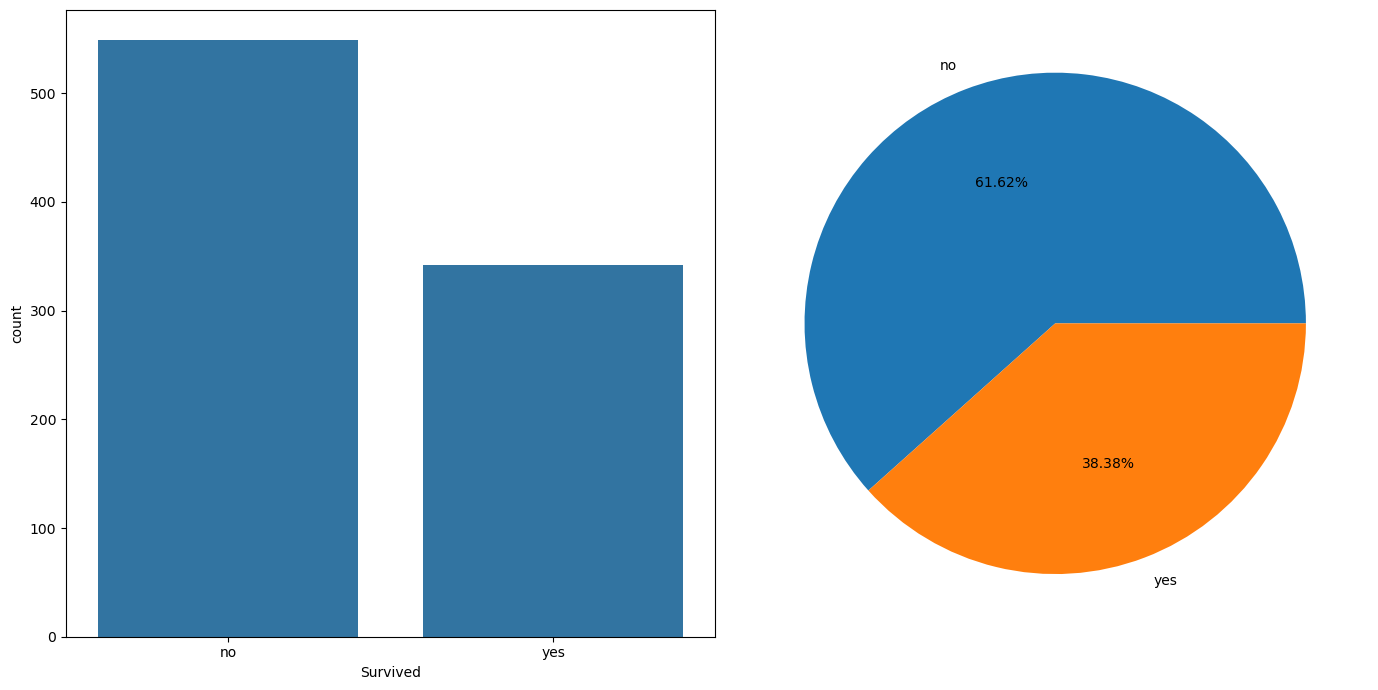

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.countplot(data=df, x="Survived", ax=axes[0])
percentage = ((df["Survived"].value_counts()/df["Survived"].size)*100)
print(percentage)
print("2 insights: Most of the people died. Data is imbalanced")
axes[1].pie(percentage, labels = percentage.index, autopct='%1.2f%%')
plt.tight_layout()
plt.show()

# Q5

2 observations:
1.Not a normal distribution
2.Distribution has positive skewness


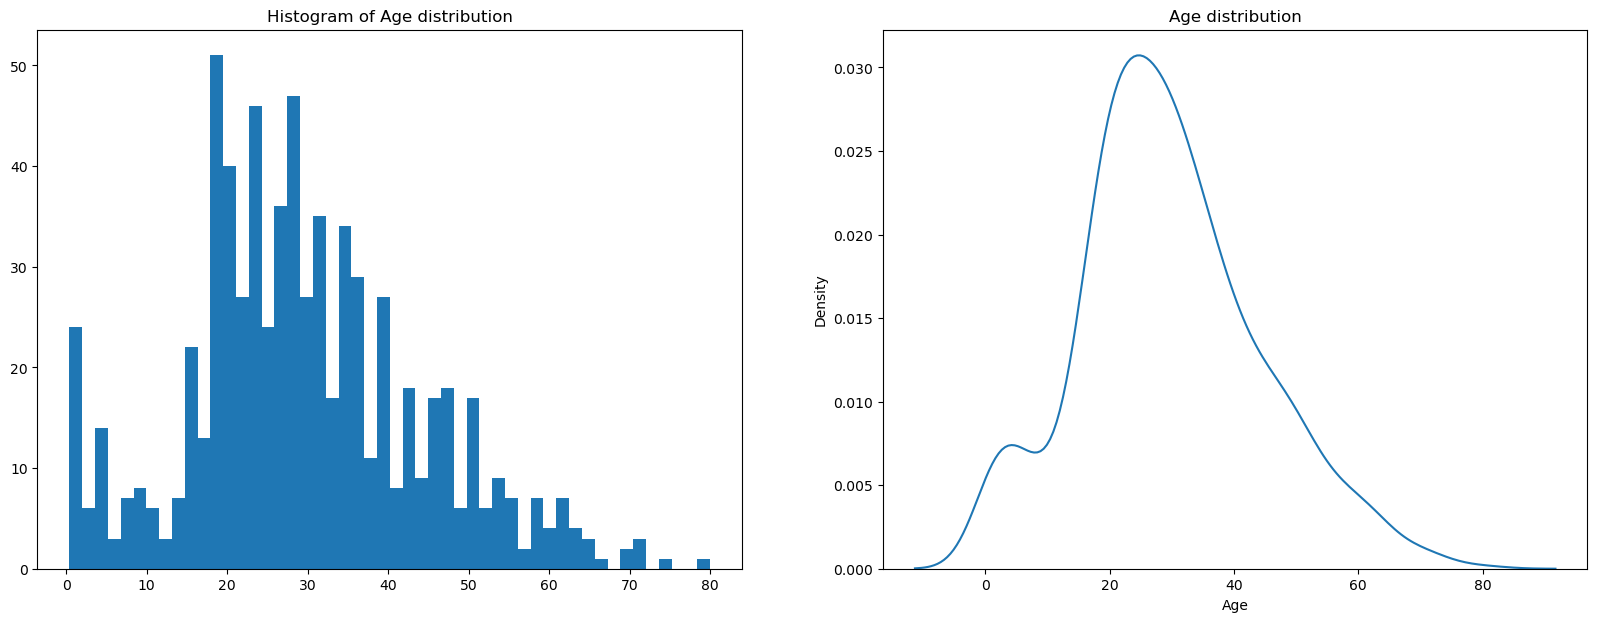

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
axes[0].hist(df["Age"], bins=50)
sns.kdeplot(data=df, x=df["Age"], ax=axes[1])
axes[0].set_title("Histogram of Age distribution")
axes[1].set_title("Age distribution")
print("2 observations:\n1.Not a normal distribution\n2.Distribution has positive skewness")
plt.show()

# Q6

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64
Two Insghts:
1. Female passengers had a much higher survival rate, with about 74.2% surviving, while only 25.8% did not survive.

2. Male passengers had a very low survival rate compared to females, with only about 18.9% surviving and 81.1% not surviving, showing a strong gender-based difference in survival outcome.



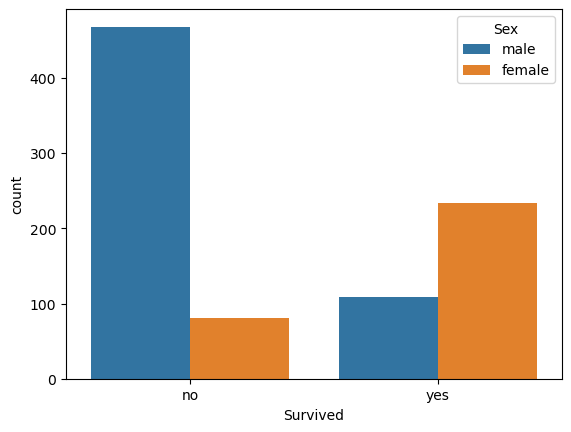

In [195]:
sns.countplot(data=df, x="Survived", hue = "Sex")
print(df[["Sex", "Survived"]].groupby("Sex").value_counts(normalize =True))
print("""Two Insghts:
1. Female passengers had a much higher survival rate, with about 74.2% surviving, while only 25.8% did not survive.

2. Male passengers had a very low survival rate compared to females, with only about 18.9% surviving and 81.1% not surviving, showing a strong gender-based difference in survival outcome.
""")
plt.show()

# Q7

Two ovserbations:
1. Fare is set based on classes
2. First class has the Heighest average Fare.


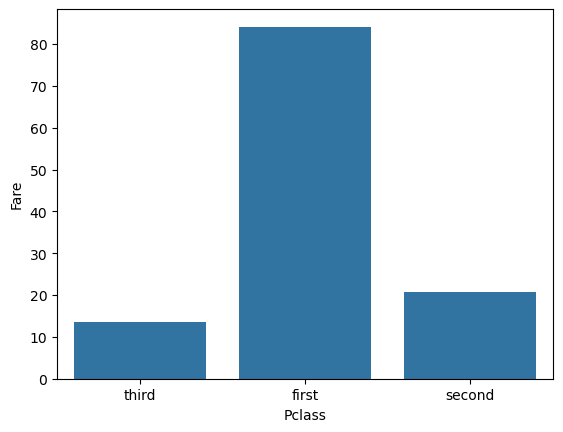

In [196]:
sns.barplot(data=df, x="Pclass", y="Fare", errorbar=None)
print("""Two ovserbations:
1. Fare is set based on classes
2. First class has the Heighest average Fare.""")

# Q8

2 insights from the graph:
1. Most people are between 20 to 40 age
2. People of 30 to 40 age have heigher survival chances


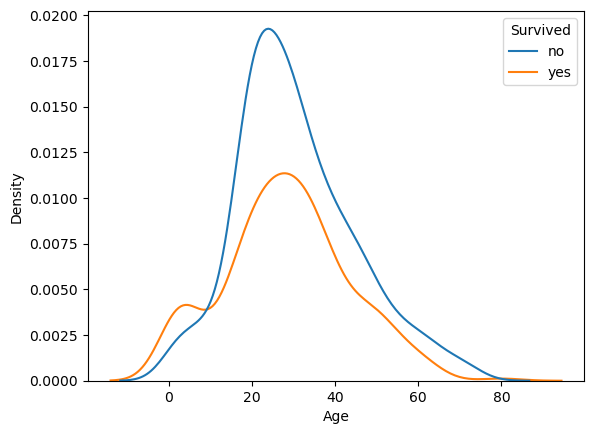

In [197]:
sns.kdeplot(data=df, x = "Age", hue = "Survived")
print("""2 insights from the graph:
1. Most people are between 20 to 40 age
2. People of 30 to 40 age have heigher survival chances""")
plt.show()

#Q9

In [198]:
dfTwo = df.drop(columns=["Name", "Ticket"]) #I set PassengerId as index, so it will not appear in any analysis or model training. 
dfTwo
trainSetX = []
trainSetY = []
testSetX = []
testSetY = []
splitter = StratifiedShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
for trainIndeies, testIndeies in splitter.split(dfTwo, dfTwo["Sex"]):
    #Stratified split, Now train test will have equeal ratio of male and female!
    trainSetX = dfTwo.iloc[trainIndeies].drop(columns=["Survived"])
    trainSetY = dfTwo.iloc[trainIndeies, 0]
    testSetX = dfTwo.iloc[testIndeies].drop(columns = ["Survived"])
    testSetY = dfTwo.iloc[testIndeies, 0]

print("Almost similar gander ratio:\n\nTrain set")
display(trainSetX[["Sex"]].value_counts(normalize=True))
print("Test Set:")
display(testSetX[["Sex"]].value_counts(normalize=True))
print(f"\n\n{trainSetX.shape}\n{testSetX.shape}")


Almost similar gander ratio:

Train set


Sex   
male      0.647472
female    0.352528
Name: proportion, dtype: float64

Test Set:


Sex   
male      0.648045
female    0.351955
Name: proportion, dtype: float64



(712, 8)
(179, 8)


# Q10

In [199]:
print(df["Age"].isnull().sum())
imputer = SimpleImputer(strategy="mean")
imputer.fit(df[["Age"]])
df["Age"]=imputer.transform(df[["Age"]])
print(df["Age"].isnull().sum())

print(df["Embarked"].isnull().sum())
imputer = SimpleImputer(strategy="most_frequent")
imputer.fit(df[["Embarked"]])
df["Embarked"] = imputer.transform(df[["Embarked"]]).ravel()
print(df["Embarked"].isnull().sum())

print(df["Cabin"].isnull().sum())
imputer = SimpleImputer(strategy="constant", fill_value="Missing", add_indicator=True)
imputer.fit(df[["Cabin"]])
df[["Cabin", "Missing Indicator"]] = imputer.transform(df[["Cabin"]])
print(df["Cabin"].isnull().sum())
display(df.isnull().sum())

177
0
2
0
687
0


Survived             0
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin                0
Embarked             0
Missing Indicator    0
dtype: int64